# Decision Tree

# 1. Definitions


## 1.1 Information Entropy(of discrete random variable)

We consider a function to describe and quantify the degree of **uncertainty or confusion** of information.      
For discrete rancom variable $X$. it's probability dirstribution is $P(X=x_i) = p_i$, we want the function(entropy) satisfies:
### 1. Continuous
i.e. The slight change of probability shouldn't lead to a jump in information volume      
**$(p)$ should be a continous function of p**

### 2. Monotonicity
$$
If\ p_1<p_2, then\ I(p_1)>I(p_2)
$$

### 3. No information for deterministic event
$$
I(1) = 0
$$


### !!!4. Additivity of independent events
If $p_1$ and $p_2$ are independent, then we have:
$$
I(p_1) + I(p_2) = I(p1\times p_2)
$$

By those axioms, obviously the function should be the logarithmic form, i.e. the **information entropy function** is defined as:
$$
I(p) = -\log_2p
$$

So the average information entropy of the total event space is:

$$
I_H(X) = -\sum_ip_i\log_2p_i
$$

> For our ML task, we can use proportion to replace probability.



## 1.2 Information Gain
For the dataset $D$ and a classification method $f$, the gain of information volume after the branch is defined as:
$$
I_G(D, f) =  I_H(D) - \sum_i \frac{|D_i|}{|D|}I_H(D_i)
$$
Where $D_i$ is the i-th subnode's dataset.

## 1.3 Gini Impurity
The Gini Impurity $I_G(D)$ is ddescribe the **impurity** of the dataset of this node. There are two definitions:
1. Chance of being incorrect if you randomly assign a label to an example in the dataset.
   1. So we have $I_G(D) = \sum_ip(i\mid D)(1-p(i\mid D))$
2. Chance of has same label if you randomly choose two distinct example in the dataset.
   1. So we have $I_G(D) = 1 - \sum_ip(i\mid D)^2$

Obviously they are equivalent mathematically.

> We offen use the second form



## 1.4 Classification Error
Here is another way to measure impurity:
$$
I_E(D) = 1-\max_i{P(i\mid D)}
$$

# 2. Definition of decision tree.

Decision tree classifiers are attractive models if we care about **interpretability**. This model breaks down our data by **making a decision** based on asking a series of questions.
e.g.
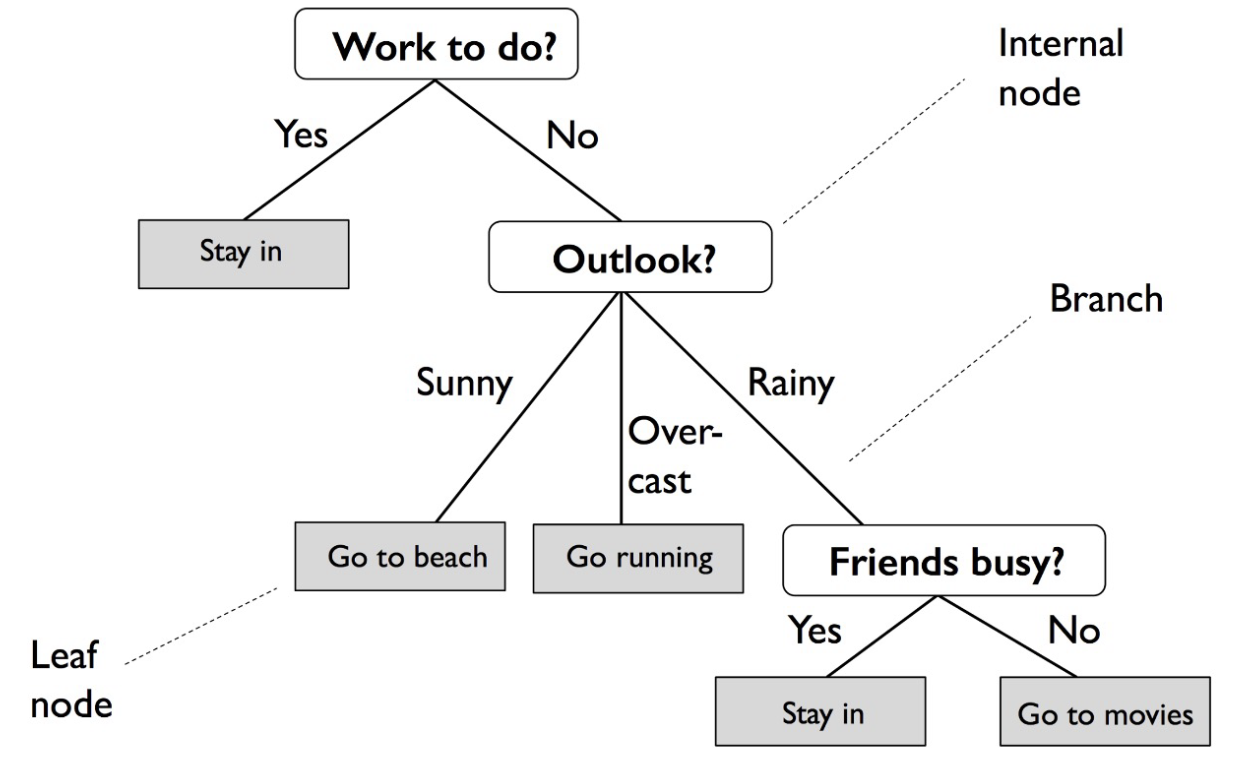-->

# 3. Three types of decision tree
The diffenence between decision trees is how to choose **question** to decision the data belong to which branch. Here three mainly types of decision tree

## 3.1 ID3(Iterative Dichotomiser 3)
ID3 try to find the feature divide to maximize the **Infromation Gain** $I_G$.

## 3.2 C4.5(Classifier Version4 improvement)
C4.5 focus on **Gain Ratio**
$$
GainRatio(D, f) = \frac{I_G(D,f)}{IV(f)}, where\\
IV(f) = - \sum_v\frac{|D^v|}{|D|}\log_2{|D^v|}{|D|} \text{ is the }\text{Intrinsic Value}
$$
where $v$ belongs the range of the feature $f$, $D^v$ is the subset of the data when feature $f=v$

## 3.3 CART(Classification And Regression Trees)
We focus on the **Gini Index**, that choose the feature that maximize the **Gain of Gini Index**:
$$
GainGini = Gini(D)-\sum_v\frac{|D^v|}{|D}Gini(D^v)
$$

In [10]:
from typing import Literal
import numpy as np

class myDecisionTree:
    class Node:
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value
    
    def __init__(self,
                 mode: Literal["ID3", "C4.5", "CART"] = "CART",
                 max_depth: int = 10
                 ):
        self.mode_ = mode
        self.max_depth_ = max_depth
        self.root_ = None
        
    def _build_tree(self, X, Y, depth):
        feature, threshold = self._split(X, Y)
        if feature is None or depth >= self.max_depth_:
            return self.Node(value=self._most_common_label(Y))
        left_indices = X[:, feature] < threshold
        right_indices = X[:, feature] >= threshold
        
        # 检查分割后是否为空
        if np.sum(left_indices) == 0 or np.sum(right_indices) == 0:
            return self.Node(value=self._most_common_label(Y))
        
        X_left, Y_left = X[left_indices], Y[left_indices]
        X_right, Y_right = X[right_indices], Y[right_indices]
        left_child = self._build_tree(X_left, Y_left, depth + 1)
        right_child = self._build_tree(X_right, Y_right, depth + 1)
        return self.Node(feature=feature, threshold=threshold, left=left_child, right=right_child)
        
    def fit(self, X, Y):
        self.root_ = self._build_tree(X, Y, 0)
    
    def _information_entropy(self, Y):
        counts = np.bincount(Y)
        return -np.sum(counts / len(Y) * np.log2(counts / len(Y) + 1e-9))
    
    def _information_gain(self, Y, left_indices, right_indices):
        H_Y = self._information_entropy(Y)
        H_left = self._information_entropy(Y[left_indices])
        H_right = self._information_entropy(Y[right_indices])
        n_left, n_right = len(left_indices), len(right_indices)
        n_total = n_left + n_right
        return H_Y - (n_left / n_total * H_left + n_right / n_total * H_right)
    
    def _gain_ratio(self, Y, left_indices, right_indices):
        gain = self._information_gain(Y, left_indices, right_indices)
        split_info = - (len(left_indices) / len(Y) * np.log2(len(left_indices) / len(Y) + 1e-9) +
                        len(right_indices) / len(Y) * np.log2(len(right_indices) / len(Y) + 1e-9))
        return gain / (split_info + 1e-9)
    
    def _gini_index(self, Y):
        counts = np.bincount(Y)
        probabilities = counts / len(Y)
        return 1 - np.sum(probabilities ** 2)
    
    def _gini_gain(self, Y, left_indices, right_indices):
        G_Y = self._gini_index(Y)
        G_left = self._gini_index(Y[left_indices])
        G_right = self._gini_index(Y[right_indices])
        n_left, n_right = len(left_indices), len(right_indices)
        n_total = n_left + n_right
        return G_Y - (n_left / n_total * G_left + n_right / n_total * G_right)
    
    def _split(self, X, Y):
        best_feature, best_threshold = None, None
        best_gain = -np.inf
        n_samples, n_features = X.shape
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_indices = X[:, feature] < threshold
                right_indices = X[:, feature] >= threshold
                if self.mode_ == "ID3":
                    gain = self._information_gain(Y, left_indices, right_indices)
                elif self.mode_ == "C4.5":
                    gain = self._gain_ratio(Y, left_indices, right_indices)
                elif self.mode_ == "CART":
                    gain = self._gini_gain(Y, left_indices, right_indices)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold
    
    def _most_common_label(self, Y):
        counts = np.bincount(Y)
        return np.argmax(counts)
    
    
    def predict(self, X):
        predictions = []
        for x in X:
            node = self.root_
            while node.value is None:
                if x[node.feature] < node.threshold:
                    node = node.left
                else:
                    node = node.right
            predictions.append(node.value)
        return np.array(predictions)

In [11]:
def test_decision_tree():
    from sklearn.datasets import load_iris
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score
    
    # Load the iris dataset
    iris = load_iris()
    X, y = iris.data, iris.target
    
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Create an instance of the decision tree classifier
    clf = myDecisionTree(mode="CART", max_depth=3)
    
    # Fit the model to the training data
    clf.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = clf.predict(X_test)
    
    # Calculate and print the accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")
    
test_decision_tree()

Accuracy: 1.00


# 4. Random Forest

Consider we use many different decision tree and combine their result, can improve the perfoemance of our model.

## 4.1 Training flow

Suppose we want to struct a **random forest** with $N$ trees.

### 4.1.1 Bootstrap Sampling 数据采样
We **randomly** sellect $N$ sample subsets **with replacement from the original training set**. Each subset should have **same size** as the original training set. Because of the randomness, for each subset:
+ About $63.2%$ data will be chosen
+ About $36.8%$ won't be chosen, which we called it **"Out-of-bag, OOB"**, will be used to verify the model.(Yet)
We randomly product the **perturbation** or data, hence the trees with different training data will has diversity in structure.

### 4.2.2 Struct the decision tree.

For each decision tree, we train a decison tree with the corresponding subset. But we don't use all the features to train the decision tree, we only randomly select $m$ features from the total $M$ features to train the decision tree, where $m < M$(usuallt we have $m = \sqrt{M}$). This is called **feature bagging**. By this way, we can further increase the diversity of the trees.

### 4.1.3 Prediction(or Aggregation)
For classification, we use **majority voting** to decide the final label.